In [1]:
import pandas as pd
import json
import ast
import re
from pathlib import Path

In [3]:
def safe_parse_json(value):
    if pd.isna(value):
        return None

    if isinstance(value, (dict, list)):
        return value

    text = str(value).strip()
    if not text:
        return None

    try:
        return json.loads(text)
    except Exception:
        pass

    try:
        return ast.literal_eval(text)
    except Exception:
        return None


def normalize_name(name):
    if not isinstance(name, str):
        return ""

    name = name.lower().strip()

    # remove file extension
    name = re.sub(r"\.(pdf|docx|doc|xlsx|xls)$", "", name)

    # replace separators/punctuation with spaces
    name = re.sub(r"[_\-–—/\\]+", " ", name)
    name = re.sub(r"[^\w\s\u0600-\u06FF]", " ", name)

    # normalize whitespace
    name = " ".join(name.split())

    return name


def names_match(gold_name, retrieved_name):
    g = normalize_name(gold_name)
    r = normalize_name(retrieved_name)

    if not g or not r:
        return False

    # exact match only
    return g == r


def extract_citation_sources(citation_value):
    parsed = safe_parse_json(citation_value)
    if not parsed or not isinstance(parsed, dict):
        return []

    citations = parsed.get("citations", [])
    if not isinstance(citations, list):
        return []

    sources = []
    for item in citations:
        if isinstance(item, dict):
            src = item.get("source")
            if src:
                sources.append(str(src).strip())

    return list(dict.fromkeys(sources))


def extract_retrieved_doc_names(api_docs_value):
    parsed = safe_parse_json(api_docs_value)
    if not parsed or not isinstance(parsed, list):
        return []

    names = []
    for item in parsed:
        if isinstance(item, dict):
            name = item.get("name")
            if name:
                names.append(str(name).strip())

    return list(dict.fromkeys(names))


def compute_row_metrics(gold_sources, retrieved_names):
    gold_unique = list(dict.fromkeys(gold_sources))
    retrieved_unique = list(dict.fromkeys(retrieved_names))

    matched_gold = set()
    matched_retrieved_idx = set()

    for gi, g in enumerate(gold_unique):
        for ri, r in enumerate(retrieved_unique):
            if names_match(g, r):
                matched_gold.add(gi)
                matched_retrieved_idx.add(ri)

    relevant_retrieved = len(matched_retrieved_idx)

    precision = relevant_retrieved / len(retrieved_unique) if retrieved_unique else 0.0
    recall = len(matched_gold) / len(gold_unique) if gold_unique else 0.0
    hit_rate = 1 if len(matched_gold) > 0 else 0
    accuracy = hit_rate

    reciprocal_rank = 0.0
    for idx, r in enumerate(retrieved_unique, start=1):
        if any(names_match(g, r) for g in gold_unique):
            reciprocal_rank = 1.0 / idx
            break

    return {
        "gold_sources": gold_unique,
        "retrieved_names": retrieved_unique,
        "gold_sources_normalized": [normalize_name(x) for x in gold_unique],
        "retrieved_names_normalized": [normalize_name(x) for x in retrieved_unique],
        "matched_gold_count": len(matched_gold),
        "matched_retrieved_count": len(matched_retrieved_idx),
        "gold_count": len(gold_unique),
        "retrieved_count": len(retrieved_unique),
        "precision": precision,
        "recall": recall,
        "hit_rate": hit_rate,
        "accuracy": accuracy,
        "mrr": reciprocal_rank,
    }

In [4]:
def evaluate_single_file(file_path):
    df = pd.read_excel(file_path)

    required_cols = ["citation", "api_relevantDocumentDtos"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{file_path} is missing columns: {missing}")

    row_results = []

    for _, row in df.iterrows():
        gold_sources = extract_citation_sources(row["citation"])
        retrieved_names = extract_retrieved_doc_names(row["api_relevantDocumentDtos"])
        metrics = compute_row_metrics(gold_sources, retrieved_names)
        row_results.append(metrics)

    metrics_df = pd.DataFrame(row_results)
    detailed_df = pd.concat([df, metrics_df], axis=1)

    summary = {
        "num_rows": len(detailed_df),
        "avg_precision": detailed_df["precision"].mean(),
        "avg_recall": detailed_df["recall"].mean(),
        "avg_hit_rate": detailed_df["hit_rate"].mean(),
        "avg_accuracy": detailed_df["accuracy"].mean(),
        "avg_mrr": detailed_df["mrr"].mean(),
    }

    return detailed_df, summary

In [5]:
agent1_base = Path(r"C:\Users\ahmed\OneDrive\Desktop\bank_h\all topic")
agent2_base = Path(r"C:\Users\ahmed\OneDrive\Desktop\bank_h\single topic")

domains = ["car", "credit card", "housing", "Personal"]

In [6]:
def find_excel_file(folder_path):
    excel_files = list(folder_path.glob("*.xlsx")) + list(folder_path.glob("*.xls"))
    
    if len(excel_files) == 0:
        raise FileNotFoundError(f"No Excel file found in: {folder_path}")
    if len(excel_files) > 1:
        raise ValueError(f"More than one Excel file found in: {folder_path}\nFiles: {excel_files}")
    
    return excel_files[0]

In [7]:
all_summaries = []
all_details = {}

for domain in domains:
    # Agent 1
    agent1_folder = agent1_base / domain
    agent1_file = find_excel_file(agent1_folder)
    agent1_detail, agent1_summary = evaluate_single_file(agent1_file)

    agent1_summary["agent"] = "agent_1"
    agent1_summary["domain"] = domain
    agent1_summary["file_name"] = agent1_file.name

    all_summaries.append(agent1_summary)
    all_details[f"agent_1_{domain}"] = agent1_detail

    # Agent 2
    agent2_folder = agent2_base / domain
    agent2_file = find_excel_file(agent2_folder)
    agent2_detail, agent2_summary = evaluate_single_file(agent2_file)

    agent2_summary["agent"] = "agent_2"
    agent2_summary["domain"] = domain
    agent2_summary["file_name"] = agent2_file.name

    all_summaries.append(agent2_summary)
    all_details[f"agent_2_{domain}"] = agent2_detail

summary_df = pd.DataFrame(all_summaries)
summary_df

,num_rows,avg_precision,avg_recall,avg_hit_rate,avg_accuracy,avg_mrr,agent,domain,file_name
0,10,0.403333,0.600000,0.800,0.800,0.575000,agent_1,car,QA_DATA - Copy_responses_car_all_2.xlsx
1,10,0.333333,0.500000,0.700,0.700,0.633333,agent_2,car,QA_DATA - Copy_responses_car_2.xlsx
2,10,0.373333,0.483333,0.900,0.900,0.750000,agent_1,credit card,QA_DATA - Copy_responses_credit cards_all_2.xlsx
3,10,0.255000,0.483333,0.800,0.800,0.558333,agent_2,credit card,QA_DATA - Copy_responses_credit_cards_2.xlsx
4,10,0.256905,0.600000,0.800,0.800,0.675000,agent_1,housing,QA_DATA - Copy_responses_housing_all_2.xlsx
5,8,0.245833,0.562500,0.625,0.625,0.500000,agent_2,housing,QA_DATA - Copy_responses_housing_2.xlsx
6,10,0.458333,0.500000,0.900,0.900,0.633333,agent_1,Personal,QA_DATA - Copy_responses_Personal_all_2.xlsx
7,10,0.295000,0.450000,0.800,0.800,0.650000,agent_2,Personal,QA_DATA - Copy_responses_Personal_2.xlsx


In [8]:
domain_comparison = summary_df.pivot(
    index="domain",
    columns="agent",
    values=["avg_precision", "avg_recall", "avg_hit_rate", "avg_mrr"]
)

domain_comparison

avg_precision           avg_recall           avg_hit_rate          \
agent             agent_1   agent_2    agent_1   agent_2      agent_1 agent_2   
domain                                                                          
Personal         0.458333  0.295000   0.500000  0.450000          0.9   0.800   
car              0.403333  0.333333   0.600000  0.500000          0.8   0.700   
credit card      0.373333  0.255000   0.483333  0.483333          0.9   0.800   
housing          0.256905  0.245833   0.600000  0.562500          0.8   0.625   

              avg_mrr            
agent         agent_1   agent_2  
domain                           
Personal     0.633333  0.650000  
car          0.575000  0.633333  
credit card  0.750000  0.558333  
housing      0.675000  0.500000

In [9]:
domain_comparison_flat = domain_comparison.copy()
domain_comparison_flat.columns = [f"{metric}_{agent}" for metric, agent in domain_comparison_flat.columns]
domain_comparison_flat = domain_comparison_flat.reset_index()

domain_comparison_flat

,domain,avg_precision_agent_1,avg_precision_agent_2,avg_recall_agent_1,avg_recall_agent_2,avg_hit_rate_agent_1,avg_hit_rate_agent_2,avg_mrr_agent_1,avg_mrr_agent_2
0,Personal,0.458333,0.295000,0.500000,0.450000,0.9,0.800,0.633333,0.650000
1,car,0.403333,0.333333,0.600000,0.500000,0.8,0.700,0.575000,0.633333
2,credit card,0.373333,0.255000,0.483333,0.483333,0.9,0.800,0.750000,0.558333
3,housing,0.256905,0.245833,0.600000,0.562500,0.8,0.625,0.675000,0.500000


In [10]:
overall_comparison = summary_df.groupby("agent")[[
    "avg_precision",
    "avg_recall",
    "avg_hit_rate",
    "avg_accuracy",
    "avg_mrr"
]].mean().reset_index()

overall_comparison

,agent,avg_precision,avg_recall,avg_hit_rate,avg_accuracy,avg_mrr
0,agent_1,0.372976,0.545833,0.85000,0.85000,0.658333
1,agent_2,0.282292,0.498958,0.73125,0.73125,0.585417


In [12]:
output_file = Path(r"C:\Users\ahmed\OneDrive\Desktop\bank_h\retrieval_comparison_output.xlsx")

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="all_file_summaries", index=False)
    domain_comparison_flat.to_excel(writer, sheet_name="domain_comparison", index=False)
    overall_comparison.to_excel(writer, sheet_name="overall_comparison", index=False)

    # optional: save detailed rows for each file
    for sheet_name, detail_df in all_details.items():
        safe_sheet_name = sheet_name[:31]  # Excel limit
        detail_df.to_excel(writer, sheet_name=safe_sheet_name, index=False)

print(f"Saved to: {output_file}")

Saved to: C:\Users\ahmed\OneDrive\Desktop\bank_h\retrieval_comparison_output.xlsx


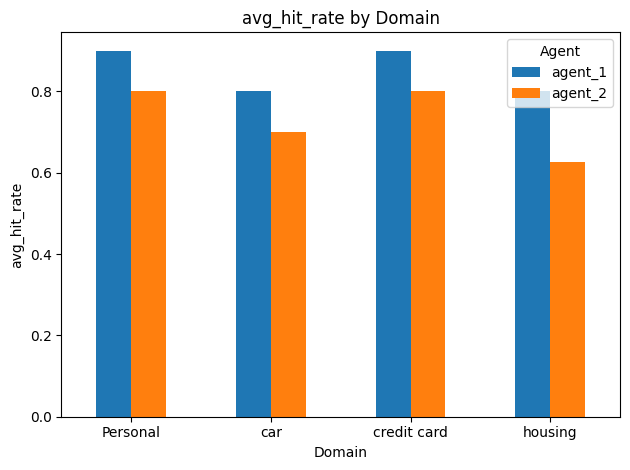

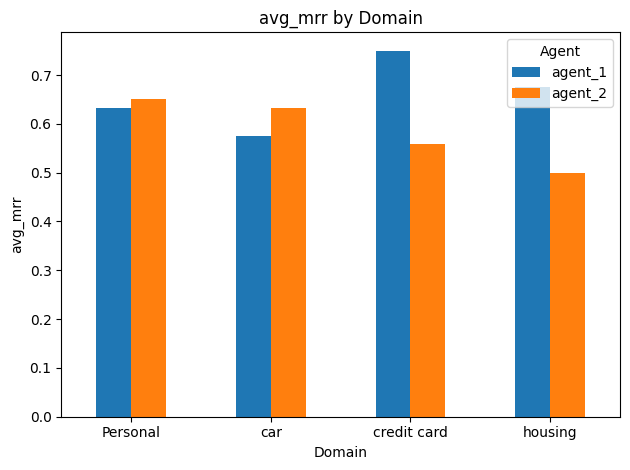

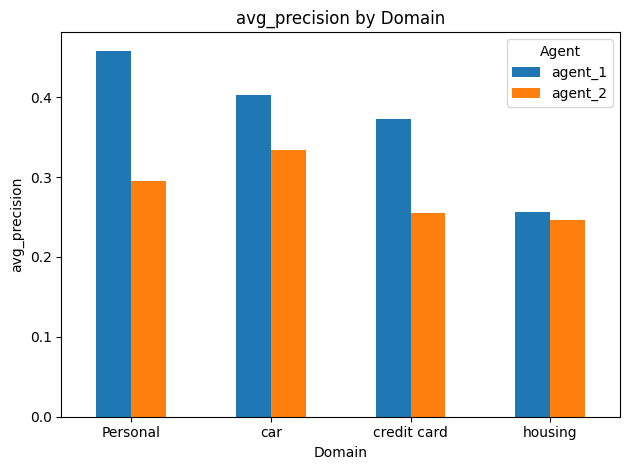

In [13]:
import matplotlib.pyplot as plt

metrics = ["avg_hit_rate", "avg_mrr", "avg_precision"]

for metric in metrics:
    pivot = summary_df.pivot(index="domain", columns="agent", values=metric)

    pivot.plot(kind="bar")
    plt.title(f"{metric} by Domain")
    plt.xlabel("Domain")
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.legend(title="Agent")
    plt.tight_layout()
    plt.show()

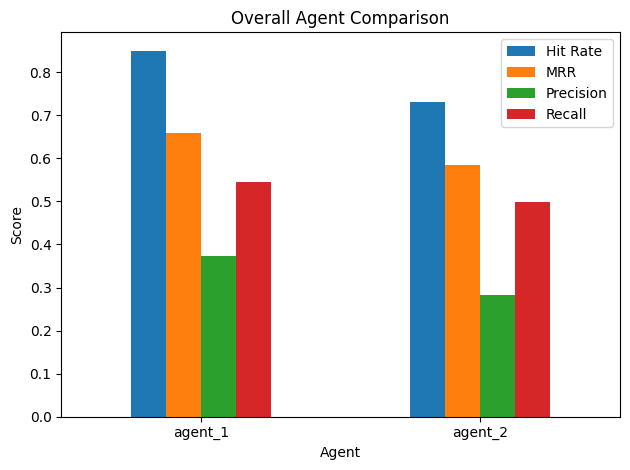

In [18]:
overall_comparison.set_index("agent")[[
    "avg_hit_rate",
    "avg_mrr",
    "avg_precision",
    "avg_recall"   # ← ده اللي ضيفناه
]].plot(kind="bar")

plt.title("Overall Agent Comparison")
plt.xlabel("Agent")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.legend(["Hit Rate", "MRR", "Precision", "Recall"])

plt.tight_layout()
plt.show()

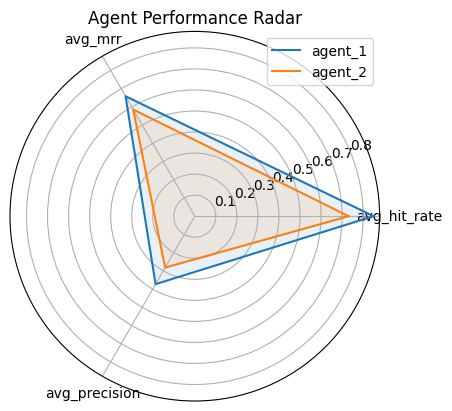

In [15]:
import numpy as np

metrics = ["avg_hit_rate", "avg_mrr", "avg_precision"]

labels = metrics
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(subplot_kw=dict(polar=True))

for i, row in overall_comparison.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row["agent"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Agent Performance Radar")
plt.legend()
plt.show()

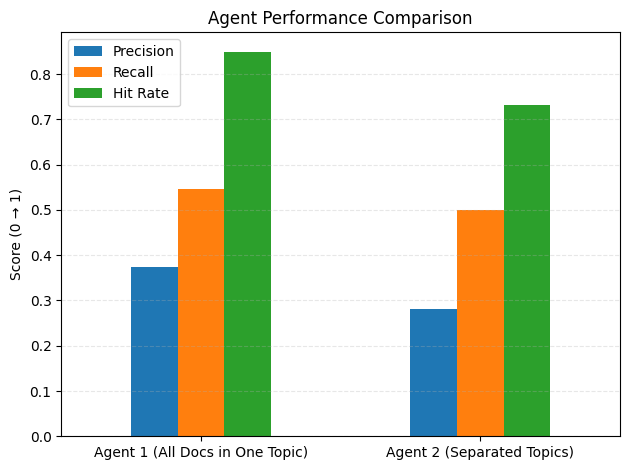

In [17]:
import matplotlib.pyplot as plt

metrics = ["avg_precision", "avg_recall", "avg_hit_rate"]

plot_df = overall_comparison.set_index("agent")[metrics]

# تغيير أسماء الـ agents
plot_df.index = [
    "Agent 1 (All Docs in One Topic)",
    "Agent 2 (Separated Topics)"
]

plot_df.plot(kind="bar")

plt.title("Agent Performance Comparison")
plt.xlabel("")
plt.ylabel("Score (0 → 1)")
plt.xticks(rotation=0)

plt.legend(["Precision", "Recall", "Hit Rate"])
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

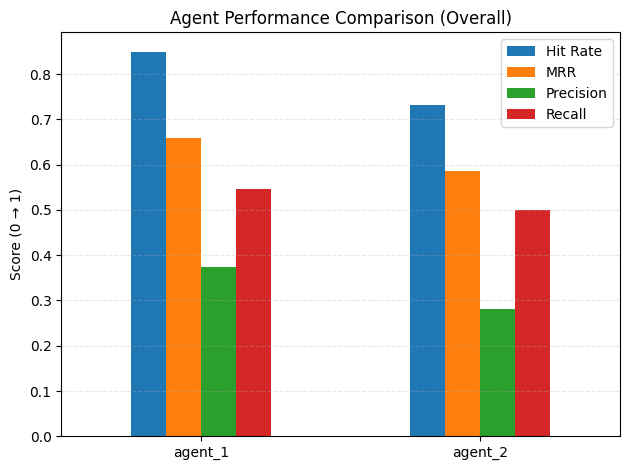

In [19]:
overall_comparison.set_index("agent")[[
    "avg_hit_rate",
    "avg_mrr",
    "avg_precision",
    "avg_recall"
]].plot(kind="bar")

plt.title("Agent Performance Comparison (Overall)")
plt.xlabel("")
plt.ylabel("Score (0 → 1)")
plt.xticks(rotation=0)

plt.legend(["Hit Rate", "MRR", "Precision", "Recall"])
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

df = overall_comparison.copy()

# تحويل كل الميتريكس لنسبة مئوية
df["precision_pct"] = df["avg_precision"] * 100
df["recall_pct"] = df["avg_recall"] * 100
df["accuracy_pct"] = df["avg_accuracy"] * 100
df["hit_rate_pct"] = df["avg_hit_rate"] * 100

print("=== Metrics as Percentage ===")
print(df[["agent", "precision_pct", "recall_pct", "accuracy_pct", "hit_rate_pct"]])

# فصل agents
a1 = df[df["agent"] == "agent_1"].iloc[0]
a2 = df[df["agent"] == "agent_2"].iloc[0]

# =========================
# الفروق (percentage points)
# =========================
precision_diff_points = a1["precision_pct"] - a2["precision_pct"]
recall_diff_points = a1["recall_pct"] - a2["recall_pct"]
accuracy_diff_points = a1["accuracy_pct"] - a2["accuracy_pct"]
hit_rate_diff_points = a1["hit_rate_pct"] - a2["hit_rate_pct"]

# =========================
# الفروق النسبية (%)
# =========================
precision_diff_percent = ((a1["precision_pct"] - a2["precision_pct"]) / a2["precision_pct"] * 100) if a2["precision_pct"] != 0 else None
recall_diff_percent = ((a1["recall_pct"] - a2["recall_pct"]) / a2["recall_pct"] * 100) if a2["recall_pct"] != 0 else None
accuracy_diff_percent = ((a1["accuracy_pct"] - a2["accuracy_pct"]) / a2["accuracy_pct"] * 100) if a2["accuracy_pct"] != 0 else None
hit_rate_diff_percent = ((a1["hit_rate_pct"] - a2["hit_rate_pct"]) / a2["hit_rate_pct"] * 100) if a2["hit_rate_pct"] != 0 else None

# =========================
# Print results
# =========================
print("\n=== Difference: Agent 1 vs Agent 2 ===")

print(f"\nPrecision:")
print(f"{a1['precision_pct']:.2f}% vs {a2['precision_pct']:.2f}%")
print(f"Difference (points): {precision_diff_points:.2f}")
print(f"Relative improvement: {precision_diff_percent:.2f}%")

print(f"\nRecall:")
print(f"{a1['recall_pct']:.2f}% vs {a2['recall_pct']:.2f}%")
print(f"Difference (points): {recall_diff_points:.2f}")
print(f"Relative improvement: {recall_diff_percent:.2f}%")

print(f"\nAccuracy:")
print(f"{a1['accuracy_pct']:.2f}% vs {a2['accuracy_pct']:.2f}%")
print(f"Difference (points): {accuracy_diff_points:.2f}")
print(f"Relative improvement: {accuracy_diff_percent:.2f}%")

print(f"\nHit Rate:")
print(f"{a1['hit_rate_pct']:.2f}% vs {a2['hit_rate_pct']:.2f}%")
print(f"Difference (points): {hit_rate_diff_points:.2f}")
print(f"Relative improvement: {hit_rate_diff_percent:.2f}%")

=== Metrics as Percentage ===
     agent  precision_pct  recall_pct  accuracy_pct  hit_rate_pct
0  agent_1      37.297619   54.583333        85.000        85.000
1  agent_2      28.229167   49.895833        73.125        73.125

=== Difference: Agent 1 vs Agent 2 ===

Precision:
37.30% vs 28.23%
Difference (points): 9.07
Relative improvement: 32.12%

Recall:
54.58% vs 49.90%
Difference (points): 4.69
Relative improvement: 9.39%

Accuracy:
85.00% vs 73.12%
Difference (points): 11.88
Relative improvement: 16.24%

Hit Rate:
85.00% vs 73.12%
Difference (points): 11.88
Relative improvement: 16.24%
